# Data analysis (QVHighlights + Moment of Untruth)

In [4]:
from collections import Counter
from pathlib import Path
from pprint import pprint
from statistics import mean

import sys
sys.path.append("../")
from diploma_project.data_layer.manifest_builder import BuildManifestConfig, build_manifest
from diploma_project.data_layer.validate_manifest import format_validation_report, validate_manifest

import matplotlib.pyplot as plt

## Описание данных

Минимальный data layer ориентирован на четыре режима:
- `positive_only` - для retrieval baseline и compression без reject
- `negative_aware_train` - для joint training с positive + negative queries
- `negative_aware_eval` - для раздельной оценки `pos`, `id_neg`, `ood_neg`
- `test_inference` - для инференса без ожидания ground truth

Канонические категории примеров:
- `pos`
- `id_neg`
- `ood_neg`

In [7]:
PROJECT_ROOT = Path("/Users/macbook/Desktop/study/ms/diploma/code")

In [8]:
config = BuildManifestConfig(
    feature_root=PROJECT_ROOT / 'data/qvhighlights/features',
    feature_modalities=('clip_features', 'slowfast_features'),
    pos_train_path=PROJECT_ROOT / 'data/qvhighlights_neg/pos_only/qvhl_pos_train.jsonl',
    pos_val_path=PROJECT_ROOT / 'data/qvhighlights_neg/pos_only/qvhl_pos_val.jsonl',
    id_neg_train_path=PROJECT_ROOT / 'data/qvhighlights_neg/indomain/qvhl_id_neg_train.jsonl',
    id_neg_val_path=PROJECT_ROOT / 'data/qvhighlights_neg/indomain/qvhl_id_neg_val.jsonl',
    ood_neg_train_path=PROJECT_ROOT / 'data/qvhighlights_neg/outofdomain/qvhl_ood_neg_train.jsonl',
    ood_neg_val_path=PROJECT_ROOT / 'data/qvhighlights_neg/outofdomain/qvhl_ood_neg_val.jsonl',
)
manifest = build_manifest(config)

## Источники данных

Локальная структура, с которой работает builder:
- positive splits: `data/qvhighlights_neg/pos_only/qvhl_pos_train.jsonl`, `data/qvhighlights_neg/pos_only/qvhl_pos_val.jsonl`
- in-domain negative splits: `data/qvhighlights_neg/indomain/qvhl_id_neg_train.jsonl`, `data/qvhighlights_neg/indomain/qvhl_id_neg_val.jsonl`
- out-of-domain negative splits: `data/qvhighlights_neg/outofdomain/qvhl_ood_neg_train.jsonl`, `data/qvhighlights_neg/outofdomain/qvhl_ood_neg_val.jsonl`
- video features: `data/qvhighlights/features/clip_features` и `data/qvhighlights/features/slowfast_features`

Manifest объединяет эти источники в согласованный формат

In [10]:
print('feature_modalities:', manifest.feature_modalities)
print('\nsource config:')
pprint(manifest.source)

feature_modalities: ['clip_features', 'slowfast_features']

source config:
{'id_neg_train_path': '/Users/macbook/Desktop/study/ms/diploma/code/data/qvhighlights_neg/indomain/qvhl_id_neg_train.jsonl',
 'id_neg_val_path': '/Users/macbook/Desktop/study/ms/diploma/code/data/qvhighlights_neg/indomain/qvhl_id_neg_val.jsonl',
 'ood_neg_train_path': '/Users/macbook/Desktop/study/ms/diploma/code/data/qvhighlights_neg/outofdomain/qvhl_ood_neg_train.jsonl',
 'ood_neg_val_path': '/Users/macbook/Desktop/study/ms/diploma/code/data/qvhighlights_neg/outofdomain/qvhl_ood_neg_val.jsonl',
 'pos_train_path': '/Users/macbook/Desktop/study/ms/diploma/code/data/qvhighlights_neg/pos_only/qvhl_pos_train.jsonl',
 'pos_val_path': '/Users/macbook/Desktop/study/ms/diploma/code/data/qvhighlights_neg/pos_only/qvhl_pos_val.jsonl',
 'protocol': 'AGENTS.md v1.0'}


## Анализ данных

### Размер сплитов

- `train_mixed = train_pos + train_id_neg + train_ood_neg`
- `val_mixed = val_pos + val_id_neg + val_ood_neg`
- negative examples получают канонический `qid` с namespace-префиксом, чтобы внутри mixed split не было коллизий по идентификаторам

In [11]:
split_sizes = {split_name: len(samples) for split_name, samples in manifest.splits.items()}
split_sizes

{'train_pos': 7218,
 'val_pos': 1550,
 'train_id_neg': 7218,
 'val_id_neg': 1550,
 'train_ood_neg': 7230,
 'val_ood_neg': 1550,
 'train_mixed': 21666,
 'val_mixed': 4650}

In [12]:
def split_summary(samples):
    label_counts = Counter(sample.label_type for sample in samples)
    unique_vids = len({sample.vid for sample in samples})
    token_lengths = [sample.num_tokens_before_compression for sample in samples if sample.num_tokens_before_compression is not None]
    query_lengths = [len(sample.query.split()) for sample in samples]
    return {
        'num_samples': len(samples),
        'label_counts': dict(label_counts),
        'unique_vids': unique_vids,
        'min_tokens': min(token_lengths) if token_lengths else None,
        'max_tokens': max(token_lengths) if token_lengths else None,
        'avg_tokens': round(mean(token_lengths), 2) if token_lengths else None,
        'min_query_words': min(query_lengths) if query_lengths else None,
        'max_query_words': max(query_lengths) if query_lengths else None,
        'avg_query_words': round(mean(query_lengths), 2) if query_lengths else None,
    }

for split_name in ['train_pos', 'val_pos', 'train_id_neg', 'val_id_neg', 'train_ood_neg', 'val_ood_neg', 'train_mixed', 'val_mixed']:
    print(f'\n{split_name}')
    pprint(split_summary(manifest.splits[split_name]))


train_pos
{'avg_query_words': 10.46,
 'avg_tokens': 74.76,
 'label_counts': {'pos': 7218},
 'max_query_words': 44,
 'max_tokens': 75,
 'min_query_words': 4,
 'min_tokens': 60,
 'num_samples': 7218,
 'unique_vids': 7100}

val_pos
{'avg_query_words': 10.49,
 'avg_tokens': 74.8,
 'label_counts': {'pos': 1550},
 'max_query_words': 45,
 'max_tokens': 75,
 'min_query_words': 4,
 'min_tokens': 60,
 'num_samples': 1550,
 'unique_vids': 1519}

train_id_neg
{'avg_query_words': 10.46,
 'avg_tokens': 74.76,
 'label_counts': {'id_neg': 7218},
 'max_query_words': 44,
 'max_tokens': 75,
 'min_query_words': 4,
 'min_tokens': 60,
 'num_samples': 7218,
 'unique_vids': 7100}

val_id_neg
{'avg_query_words': 10.49,
 'avg_tokens': 74.8,
 'label_counts': {'id_neg': 1550},
 'max_query_words': 45,
 'max_tokens': 75,
 'min_query_words': 4,
 'min_tokens': 60,
 'num_samples': 1550,
 'unique_vids': 1519}

train_ood_neg
{'avg_query_words': 12.9,
 'avg_tokens': 74.77,
 'label_counts': {'ood_neg': 7230},
 'max_query

### Примеры нормализованных samples

Ниже удобно посмотреть, как один и тот же data layer представляет разные типы примеров

Что стоит заметить:
- positive sample хранит реальные `gt_windows`
- negative sample хранит `gt_windows=None`
- `negative_subtype` различает `id` и `ood`
- `features` содержат metadata по каждой modality
- `meta['source_qid']` сохраняет исходный идентификатор из raw split-файла

In [13]:
def preview_sample(split_name, index=0):
    sample = manifest.splits[split_name][index]
    payload = sample.to_dict()
    compact = {
        'qid': payload['qid'],
        'source_qid': payload['meta'].get('source_qid'),
        'split': payload['split'],
        'label_type': payload['label_type'],
        'negative_subtype': payload['negative_subtype'],
        'query': payload['query'],
        'vid': payload['vid'],
        'gt_windows': payload['gt_windows'],
        'duration': payload['duration'],
        'num_tokens_before_compression': payload['num_tokens_before_compression'],
        'feature_modalities': list(payload['features'].keys()),
    }
    print(f'=== {split_name} ===')
    pprint(compact)

for split_name in ['train_pos', 'train_id_neg', 'train_ood_neg']:
    preview_sample(split_name)
    print()

=== train_pos ===
{'duration': 150.0,
 'feature_modalities': ['clip_features', 'slowfast_features'],
 'gt_windows': [[72.0, 82.0],
                [84.0, 94.0],
                [96.0, 106.0],
                [108.0, 118.0],
                [120.0, 130.0],
                [136.0, 142.0],
                [144.0, 146.0]],
 'label_type': 'pos',
 'negative_subtype': None,
 'num_tokens_before_compression': 75,
 'qid': 9769,
 'query': 'some military patriots takes us through their safety procedures and '
          'measures.',
 'source_qid': 9769,
 'split': 'train',
 'vid': 'j7rJstUseKg_360.0_510.0'}

=== train_id_neg ===
{'duration': 150.0,
 'feature_modalities': ['clip_features', 'slowfast_features'],
 'gt_windows': None,
 'label_type': 'id_neg',
 'negative_subtype': 'id',
 'num_tokens_before_compression': 75,
 'qid': 'id_neg:9769',
 'query': 'some military patriots takes us through their safety procedures and '
          'measures.',
 'source_qid': 9769,
 'split': 'train',
 'vid': '8EG4DqJ

### Быстрые наблюдения по данным

По текущей локальной структуре можно сделать несколько первых наблюдений:
- positive и ID-negative train/val split-ы сбалансированы по числу примеров
- OOD-negative train чуть больше positive/ID train, а OOD-negative val совпадает по размеру с остальными val split-ами
- samples обычно имеют обе modality features: `clip_features` и `slowfast_features`
- длина видеопоследовательности доступна заранее через `num_tokens_before_compression`, что удобно для будущих compression-абляций
- отрицательные примеры уже нормализованы к канонической negative-aware форме, пригодной для reject-or-retrieve evaluation

### Распределения по длине feature sequence

Этот блок помогает понять, с какими исходными длинами видео-токенов нам предстоит работать до compression. Это особенно полезно перед постановкой budget levels для retention/compression policy.

train_pos {'min': 60, 'max': 75, 'avg': 74.76, 'median_like': 75, 'unique_lengths': 16}
train_id_neg {'min': 60, 'max': 75, 'avg': 74.76, 'median_like': 75, 'unique_lengths': 16}
train_ood_neg {'min': 60, 'max': 75, 'avg': 74.77, 'median_like': 75, 'unique_lengths': 16}
train_mixed {'min': 60, 'max': 75, 'avg': 74.76, 'median_like': 75, 'unique_lengths': 16}
val_mixed {'min': 60, 'max': 75, 'avg': 74.8, 'median_like': 75, 'unique_lengths': 14}


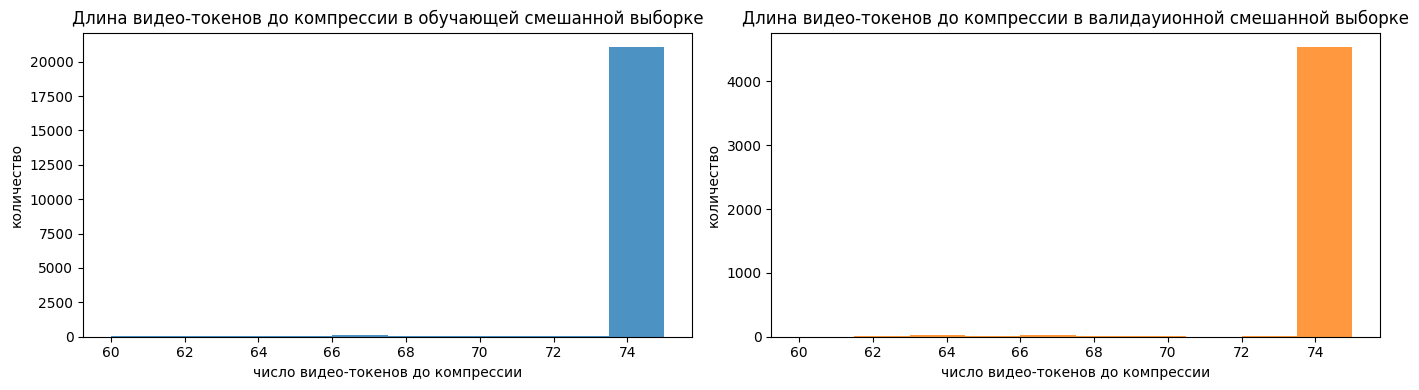

In [24]:
token_lengths_by_split = {
    split_name: [sample.num_tokens_before_compression for sample in samples if sample.num_tokens_before_compression is not None]
    for split_name, samples in manifest.splits.items()
}

for split_name in ['train_pos', 'train_id_neg', 'train_ood_neg', 'train_mixed', 'val_mixed']:
    values = token_lengths_by_split[split_name]
    print(split_name, {
        'min': min(values),
        'max': max(values),
        'avg': round(mean(values), 2),
        'median_like': values[len(values) // 2],
        'unique_lengths': len(set(values)),
    })

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(token_lengths_by_split['train_mixed'], bins=10, color='#1f77b4', alpha=0.8)
axes[0].set_title('Длина видео-токенов до компрессии в обучающей смешанной выборке')
axes[0].set_xlabel('число видео-токенов до компрессии')
axes[0].set_ylabel('количество')

axes[1].hist(token_lengths_by_split['val_mixed'], bins=10, color='#ff7f0e', alpha=0.8)
axes[1].set_title('Длина видео-токенов до компрессии в валидауионной смешанной выборке')
axes[1].set_xlabel('число видео-токенов до компрессии')
axes[1].set_ylabel('количество')
plt.tight_layout()
plt.show()


### Распределения по длине текстовых запросов

Длина query важна как минимум по двум причинам:
- она помогает понять сложность текстовой части выборки;
- позже это может быть полезно при анализе того, насколько query-aware compression чувствителен к более коротким или длинным описаниям.

train_pos {'min_words': 4, 'max_words': 44, 'avg_words': 10.46, 'num_queries': 7218}
train_id_neg {'min_words': 4, 'max_words': 44, 'avg_words': 10.46, 'num_queries': 7218}
train_ood_neg {'min_words': 5, 'max_words': 28, 'avg_words': 12.9, 'num_queries': 7230}
train_mixed {'min_words': 4, 'max_words': 44, 'avg_words': 11.28, 'num_queries': 21666}
val_mixed {'min_words': 4, 'max_words': 45, 'avg_words': 11.31, 'num_queries': 4650}


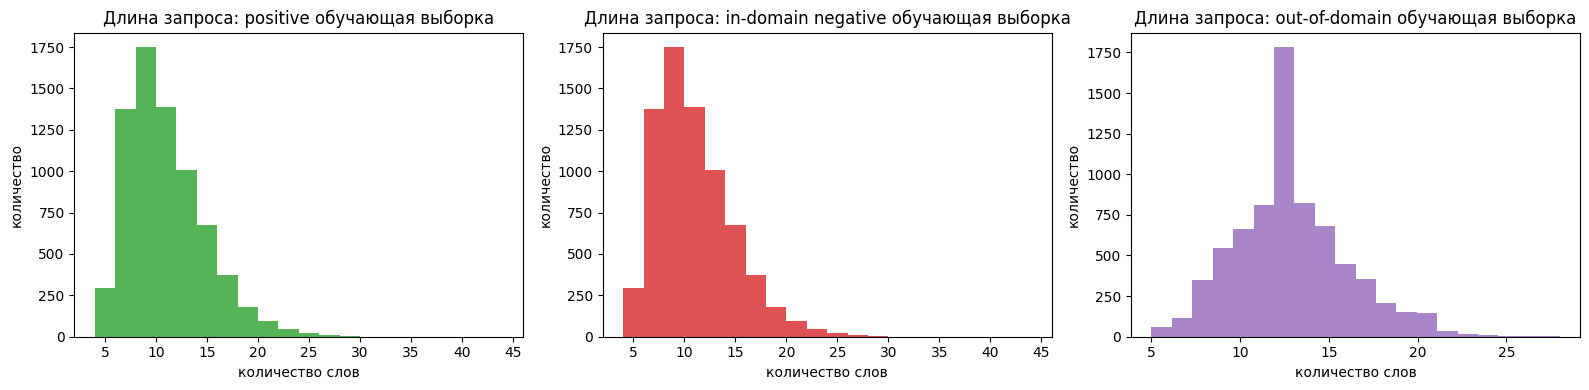

In [28]:
query_lengths_by_split = {
    split_name: [len(sample.query.split()) for sample in samples]
    for split_name, samples in manifest.splits.items()
}

for split_name in ['train_pos', 'train_id_neg', 'train_ood_neg', 'train_mixed', 'val_mixed']:
    values = query_lengths_by_split[split_name]
    print(split_name, {
        'min_words': min(values),
        'max_words': max(values),
        'avg_words': round(mean(values), 2),
        'num_queries': len(values),
    })

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_splits = ['train_pos', 'train_id_neg', 'train_ood_neg']
plot_splits_legend = {
    'train_pos': 'positive обучающая выборка', 
    'train_id_neg': 'in-domain negative обучающая выборка', 
    'train_ood_neg': 'out-of-domain обучающая выборка'
}
colors = ['#2ca02c', '#d62728', '#9467bd']
for ax, split_name, color in zip(axes, plot_splits, colors):
    ax.hist(query_lengths_by_split[split_name], bins=20, color=color, alpha=0.8)
    ax.set_title(f'Длина запроса: {plot_splits_legend[split_name]}')
    ax.set_xlabel('количество слов')
    ax.set_ylabel('количество')
plt.tight_layout()
plt.show()

### Пересечения между positive и negative наборами

Здесь мы смотрим на два типа пересечений:
- по `vid`, чтобы понять, насколько примеры делят одни и те же видео-отрезки;
- по `source_qid`, чтобы увидеть, когда negative benchmark наследует query identity от positive постановки.

Второй пункт особенно важен для in-domain negatives: там часто используется тот же исходный query id, но с другим video context. Именно поэтому канонический manifest namespacе-ит `qid` для negatives.

In [19]:
pos_all = manifest.splits['train_pos'] + manifest.splits['val_pos']
id_all = manifest.splits['train_id_neg'] + manifest.splits['val_id_neg']
ood_all = manifest.splits['train_ood_neg'] + manifest.splits['val_ood_neg']

pos_vids = {sample.vid for sample in pos_all}
id_vids = {sample.vid for sample in id_all}
ood_vids = {sample.vid for sample in ood_all}

pos_source_qids = {sample.meta['source_qid'] for sample in pos_all}
id_source_qids = {sample.meta['source_qid'] for sample in id_all}
ood_source_qids = {sample.meta['source_qid'] for sample in ood_all}

overlap_summary = {
    'vid_overlap': {
        'pos_vs_id': len(pos_vids & id_vids),
        'pos_vs_ood': len(pos_vids & ood_vids),
        'id_vs_ood': len(id_vids & ood_vids),
        'pos_only_vids': len(pos_vids - id_vids - ood_vids),
        'id_only_vids': len(id_vids - pos_vids - ood_vids),
        'ood_only_vids': len(ood_vids - pos_vids - id_vids),
    },
    'source_qid_overlap': {
        'pos_vs_id': len(pos_source_qids & id_source_qids),
        'pos_vs_ood': len(pos_source_qids & ood_source_qids),
        'id_vs_ood': len(id_source_qids & ood_source_qids),
    },
}
pprint(overlap_summary)

{'source_qid_overlap': {'id_vs_ood': 0, 'pos_vs_id': 8768, 'pos_vs_ood': 0},
 'vid_overlap': {'id_only_vids': 0,
                 'id_vs_ood': 8619,
                 'ood_only_vids': 0,
                 'pos_only_vids': 0,
                 'pos_vs_id': 8619,
                 'pos_vs_ood': 8619}}


In [20]:
shared_pos_id_vids = sorted(pos_vids & id_vids)[:10]
shared_pos_ood_vids = sorted(pos_vids & ood_vids)[:10]
shared_pos_id_source_qids = sorted(pos_source_qids & id_source_qids)[:10]
shared_pos_ood_source_qids = sorted(pos_source_qids & ood_source_qids)[:10]

print('Example shared vids: pos vs id')
print(shared_pos_id_vids)
print('\nExample shared vids: pos vs ood')
print(shared_pos_ood_vids)
print('\nExample shared source_qids: pos vs id')
print(shared_pos_id_source_qids)
print('\nExample shared source_qids: pos vs ood')
print(shared_pos_ood_source_qids)

Example shared vids: pos vs id
['--a6qL3eL0c_210.0_360.0', '--a6qL3eL0c_360.0_510.0', '--a6qL3eL0c_510.0_660.0', '--a6qL3eL0c_60.0_210.0', '--d84Ars5ng_210.0_360.0', '--d84Ars5ng_360.0_510.0', '--d84Ars5ng_60.0_210.0', '--ePzhMQU1w_210.0_360.0', '--ePzhMQU1w_360.0_510.0', '--ePzhMQU1w_60.0_210.0']

Example shared vids: pos vs ood
['--a6qL3eL0c_210.0_360.0', '--a6qL3eL0c_360.0_510.0', '--a6qL3eL0c_510.0_660.0', '--a6qL3eL0c_60.0_210.0', '--d84Ars5ng_210.0_360.0', '--d84Ars5ng_360.0_510.0', '--d84Ars5ng_60.0_210.0', '--ePzhMQU1w_210.0_360.0', '--ePzhMQU1w_360.0_510.0', '--ePzhMQU1w_60.0_210.0']

Example shared source_qids: pos vs id
[0, 1, 2, 4, 5, 6, 7, 8, 9, 10]

Example shared source_qids: pos vs ood
[]


### Exploratory: candidate budget settings для compression

Этот блок не является основным результатом по методологии и не заменяет будущие retrieval/reject эксперименты. Его цель более скромная: заранее прикинуть, какие budget levels разумно прогонять на этапе compression-абляций.

Мы смотрим на budget ratios как на долю сохраняемых токенов от исходной длины sequence.

In [21]:
candidate_retained_ratios = [1.0, 0.75, 0.5, 0.33, 0.25, 0.1]
base_tokens = [sample.num_tokens_before_compression for sample in manifest.splits['train_mixed'] if sample.num_tokens_before_compression is not None]
avg_base_tokens = mean(base_tokens)

budget_table = []
for ratio in candidate_retained_ratios:
    retained = avg_base_tokens * ratio
    budget_table.append({
        'retained_token_ratio': ratio,
        'avg_tokens_before': round(avg_base_tokens, 2),
        'avg_tokens_after': round(retained, 2),
        'compression_ratio': round(avg_base_tokens / retained, 2) if retained else None,
        'avg_tokens_removed': round(avg_base_tokens - retained, 2),
    })

budget_table

[{'retained_token_ratio': 1.0,
  'avg_tokens_before': 74.76,
  'avg_tokens_after': 74.76,
  'compression_ratio': 1.0,
  'avg_tokens_removed': 0.0},
 {'retained_token_ratio': 0.75,
  'avg_tokens_before': 74.76,
  'avg_tokens_after': 56.07,
  'compression_ratio': 1.33,
  'avg_tokens_removed': 18.69},
 {'retained_token_ratio': 0.5,
  'avg_tokens_before': 74.76,
  'avg_tokens_after': 37.38,
  'compression_ratio': 2.0,
  'avg_tokens_removed': 37.38},
 {'retained_token_ratio': 0.33,
  'avg_tokens_before': 74.76,
  'avg_tokens_after': 24.67,
  'compression_ratio': 3.03,
  'avg_tokens_removed': 50.09},
 {'retained_token_ratio': 0.25,
  'avg_tokens_before': 74.76,
  'avg_tokens_after': 18.69,
  'compression_ratio': 4.0,
  'avg_tokens_removed': 56.07},
 {'retained_token_ratio': 0.1,
  'avg_tokens_before': 74.76,
  'avg_tokens_after': 7.48,
  'compression_ratio': 10.0,
  'avg_tokens_removed': 67.29}]

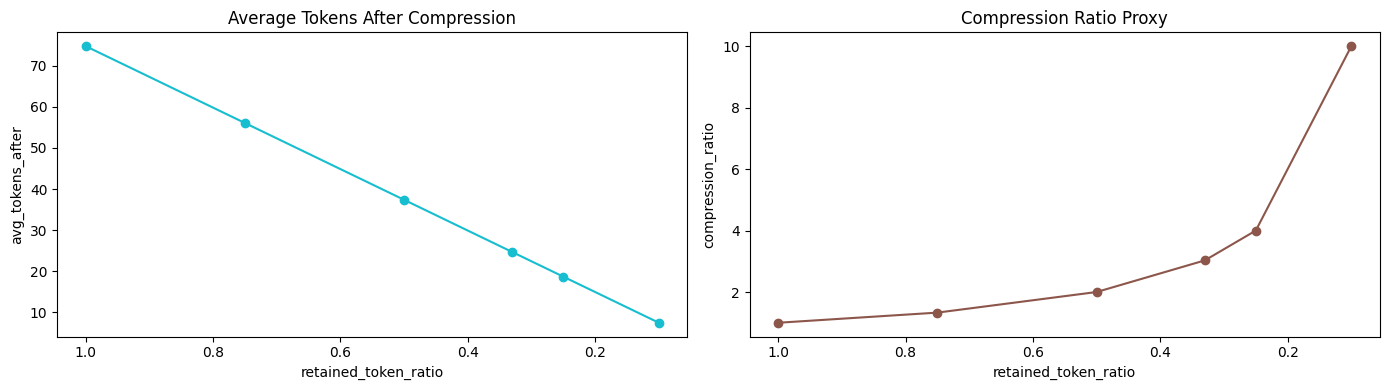

In [22]:
ratios = [row['retained_token_ratio'] for row in budget_table]
avg_after = [row['avg_tokens_after'] for row in budget_table]
comp = [row['compression_ratio'] for row in budget_table]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(ratios, avg_after, marker='o', color='#17becf')
axes[0].set_title('Average Tokens After Compression')
axes[0].set_xlabel('retained_token_ratio')
axes[0].set_ylabel('avg_tokens_after')
axes[0].invert_xaxis()

axes[1].plot(ratios, comp, marker='o', color='#8c564b')
axes[1].set_title('Compression Ratio Proxy')
axes[1].set_xlabel('retained_token_ratio')
axes[1].set_ylabel('compression_ratio')
axes[1].invert_xaxis()
plt.tight_layout()
plt.show()

Если использовать этот ноутбук как подготовку к compression-абляциям, то разумная стартовая сетка budget settings может выглядеть так:
- мягкое сжатие: `0.75`;
- среднее сжатие: `0.5`;
- агрессивное сжатие: `0.33` или `0.25`;
- экстремальный stress-test: `0.1`.

Почему это полезно:
- такая сетка покрывает и практический режим, и сильное сжатие;
- она хорошо сочетается с будущей Pareto-style сводкой из `AGENTS.md`;
- её можно применять одинаково для positive-only и joint compression experiments, не меняя остальной protocol.

Важно помнить:
- текущий блок оценивает только геометрию budgets по исходной длине токенов;
- retrieval/reject/latency результаты должны измеряться отдельно и уже на обученных/запущенных моделях.

##  Sanity checks

Валидация manifest проверяет:
- присутствие `vid` в feature storage;
- уникальность `qid` внутри каждого split;
- корректность `gt_windows` для `pos` и negatives;
- положительность `duration`, если она задана;
- непустые feature sequences;
- отсутствие overlap между `train`, `val`, `test`.

In [23]:
report = validate_manifest(manifest)
print(format_validation_report(report))

valid: True
checked_splits: train_pos, val_pos, train_id_neg, val_id_neg, train_ood_neg, val_ood_neg, train_mixed, val_mixed
sample_count[train_pos]: 7218
sample_count[val_pos]: 1550
sample_count[train_id_neg]: 7218
sample_count[val_id_neg]: 1550
sample_count[train_ood_neg]: 7230
sample_count[val_ood_neg]: 1550
sample_count[train_mixed]: 21666
sample_count[val_mixed]: 4650
issues: none
